# 02 - Feature Extraction for Classical ML Models

**Cycle Rack Audio Classification Project**

This notebook extracts features from preprocessed audio files for classical machine learning models.

## Features Extracted:

### Priority 1 - Essential Features:
- **MFCCs**: 13 coefficients (expandable to 40)
- **Spectral Centroid**: Frequency center of mass
- **Spectral Rolloff**: 85% energy threshold frequency
- **Zero Crossing Rate (ZCR)**: Signal sign change rate
- **RMS Energy**: Root mean square energy

### Priority 2 - Highly Recommended:
- **Spectral Bandwidth**: Frequency range with significant energy
- **Spectral Contrast**: Peak-to-valley spectrum differences (7 bands)

### Statistical Aggregation:
- Mean, Standard Deviation, Median for each feature

In [1]:
# Import required libraries
import os
import sys
import numpy as np
import pandas as pd
import librosa
import librosa.display
from pathlib import Path
from tqdm import tqdm
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler, MinMaxScaler
import joblib
import warnings
warnings.filterwarnings('ignore')

# Set up plotting style
plt.style.use('seaborn-v0_8')
sns.set_palette("husl")

print("Libraries imported successfully!")
print(f"Librosa version: {librosa.__version__}")
print(f"NumPy version: {np.__version__}")

Libraries imported successfully!
Librosa version: 0.11.0
NumPy version: 2.3.4


## Configuration and Path Setup

In [2]:
# Get current working directory and set up paths
# Notebook is in /project/notebooks/, need to access /project/data/
NOTEBOOK_DIR = Path.cwd()
PROJECT_ROOT = NOTEBOOK_DIR.parent  # Go up one level to project root

# Define data paths relative to project root
DATA_DIR = PROJECT_ROOT / "data"
PROCESSED_DIR = DATA_DIR / "processed"
FEATURES_DIR = DATA_DIR / "features"

# Create features directory if it doesn't exist
FEATURES_DIR.mkdir(parents=True, exist_ok=True)

# Verify paths exist
print("Path Configuration:")
print(f"  Notebook directory: {NOTEBOOK_DIR}")
print(f"  Project root: {PROJECT_ROOT}")
print(f"  Data directory: {DATA_DIR}")
print(f"  Processed audio: {PROCESSED_DIR}")
print(f"  Features output: {FEATURES_DIR}")
print(f"\nPath checks:")
print(f"  Processed directory exists: {PROCESSED_DIR.exists()}")
print(f"  Features directory exists: {FEATURES_DIR.exists()}")

# Classes to process
CLASSES = ['background', 'angle_grinder', 'other_power_tools']

# Check for class folders
print(f"\nClass folder checks:")
for class_name in CLASSES:
    class_path = PROCESSED_DIR / class_name
    exists = class_path.exists()
    if exists:
        n_files = len(list(class_path.glob("*.wav")))
        print(f"  {class_name}: ✓ ({n_files} audio files)")
    else:
        print(f"  {class_name}: ✗ (folder not found)")

# Feature extraction parameters
CONFIG = {
    'N_MFCC_START': 13,  # Start with 13 MFCCs
    'N_MFCC_MAX': 40,    # Can expand to 40 if needed
    'SPECTRAL_ROLLOFF_PERCENT': 0.85,  # 85% energy threshold
    'FRAME_LENGTH': 2048,  # From preprocessing
    'HOP_LENGTH': 512,     # From preprocessing
    'SAMPLE_RATE': 16000,  # Target sample rate
    'SCALING_METHOD': 'standard'  # 'standard' or 'minmax'
}

print(f"\nFeature Extraction Configuration:")
for key, value in CONFIG.items():
    print(f"  {key}: {value}")

Path Configuration:
  Notebook directory: /workspaces/BikeAIv2/notebooks
  Project root: /workspaces/BikeAIv2
  Data directory: /workspaces/BikeAIv2/data
  Processed audio: /workspaces/BikeAIv2/data/processed
  Features output: /workspaces/BikeAIv2/data/features

Path checks:
  Processed directory exists: True
  Features directory exists: True

Class folder checks:
  background: ✓ (1346 audio files)
  angle_grinder: ✓ (30 audio files)
  other_power_tools: ✓ (23 audio files)

Feature Extraction Configuration:
  N_MFCC_START: 13
  N_MFCC_MAX: 40
  SPECTRAL_ROLLOFF_PERCENT: 0.85
  FRAME_LENGTH: 2048
  HOP_LENGTH: 512
  SAMPLE_RATE: 16000
  SCALING_METHOD: standard


## Feature Extraction Functions

In [3]:
def extract_priority1_features(y, sr, config):
    """
    Extract Priority 1 Essential Features.
    
    Args:
        y (np.array): Audio time series
        sr (int): Sample rate
        config (dict): Configuration parameters
    
    Returns:
        dict: Dictionary of features with frame-wise values
    """
    features = {}
    
    # MFCCs (13 coefficients)
    mfccs = librosa.feature.mfcc(
        y=y, 
        sr=sr, 
        n_mfcc=config['N_MFCC_START'],
        n_fft=config['FRAME_LENGTH'],
        hop_length=config['HOP_LENGTH']
    )
    for i in range(config['N_MFCC_START']):
        features[f'mfcc_{i+1}'] = mfccs[i]
    
    # Spectral Centroid
    spectral_centroid = librosa.feature.spectral_centroid(
        y=y, 
        sr=sr,
        n_fft=config['FRAME_LENGTH'],
        hop_length=config['HOP_LENGTH']
    )[0]
    features['spectral_centroid'] = spectral_centroid
    
    # Spectral Rolloff
    spectral_rolloff = librosa.feature.spectral_rolloff(
        y=y, 
        sr=sr,
        roll_percent=config['SPECTRAL_ROLLOFF_PERCENT'],
        n_fft=config['FRAME_LENGTH'],
        hop_length=config['HOP_LENGTH']
    )[0]
    features['spectral_rolloff'] = spectral_rolloff
    
    # Zero Crossing Rate
    zcr = librosa.feature.zero_crossing_rate(
        y,
        frame_length=config['FRAME_LENGTH'],
        hop_length=config['HOP_LENGTH']
    )[0]
    features['zcr'] = zcr
    
    # RMS Energy
    rms = librosa.feature.rms(
        y=y,
        frame_length=config['FRAME_LENGTH'],
        hop_length=config['HOP_LENGTH']
    )[0]
    features['rms_energy'] = rms
    
    return features


def extract_priority2_features(y, sr, config):
    """
    Extract Priority 2 Highly Recommended Features.
    
    Args:
        y (np.array): Audio time series
        sr (int): Sample rate
        config (dict): Configuration parameters
    
    Returns:
        dict: Dictionary of features with frame-wise values
    """
    features = {}
    
    # Spectral Bandwidth
    spectral_bandwidth = librosa.feature.spectral_bandwidth(
        y=y, 
        sr=sr,
        n_fft=config['FRAME_LENGTH'],
        hop_length=config['HOP_LENGTH']
    )[0]
    features['spectral_bandwidth'] = spectral_bandwidth
    
    # Spectral Contrast (7 bands by default)
    spectral_contrast = librosa.feature.spectral_contrast(
        y=y, 
        sr=sr,
        n_fft=config['FRAME_LENGTH'],
        hop_length=config['HOP_LENGTH']
    )
    for i in range(spectral_contrast.shape[0]):
        features[f'spectral_contrast_{i+1}'] = spectral_contrast[i]
    
    return features


def aggregate_statistics(features_dict):
    """
    Aggregate statistics for each feature: mean, std, median.
    
    Args:
        features_dict (dict): Dictionary with feature names as keys and arrays as values
    
    Returns:
        dict: Dictionary with aggregated statistics
    """
    aggregated = {}
    
    for feature_name, feature_values in features_dict.items():
        aggregated[f'{feature_name}_mean'] = np.mean(feature_values)
        aggregated[f'{feature_name}_std'] = np.std(feature_values)
        aggregated[f'{feature_name}_median'] = np.median(feature_values)
    
    return aggregated


def extract_all_features(audio_path, config):
    """
    Complete feature extraction pipeline for a single audio file.
    
    Args:
        audio_path (Path): Path to audio file
        config (dict): Configuration parameters
    
    Returns:
        tuple: (features_dict, success_flag)
    """
    try:
        # Load audio
        y, sr = librosa.load(audio_path, sr=config['SAMPLE_RATE'])
        
        # Extract Priority 1 features
        priority1_features = extract_priority1_features(y, sr, config)
        
        # Extract Priority 2 features
        priority2_features = extract_priority2_features(y, sr, config)
        
        # Combine all features
        all_features = {**priority1_features, **priority2_features}
        
        # Aggregate statistics
        aggregated_features = aggregate_statistics(all_features)
        
        # Add metadata
        aggregated_features['filename'] = audio_path.name
        aggregated_features['duration'] = len(y) / sr
        
        return aggregated_features, True
        
    except Exception as e:
        print(f"Error processing {audio_path.name}: {str(e)}")
        return None, False

print("Feature extraction functions defined successfully!")

Feature extraction functions defined successfully!


## Batch Feature Extraction

In [4]:
def process_all_classes(processed_dir, classes, config):
    """
    Process all audio files from all classes and extract features.
    
    Args:
        processed_dir (Path): Path to processed audio directory
        classes (list): List of class names
        config (dict): Configuration parameters
    
    Returns:
        tuple: (features_dataframe, processing_statistics)
    """
    all_features = []
    all_labels = []
    processing_stats = {cls: {'success': 0, 'failed': 0} for cls in classes}
    
    for class_label in classes:
        class_dir = processed_dir / class_label
        
        if not class_dir.exists():
            print(f"⚠ Warning: Class directory not found: {class_dir}")
            continue
        
        audio_files = list(class_dir.glob("*.wav"))
        
        print(f"\n{'='*60}")
        print(f"Processing class: {class_label}")
        print(f"Total files: {len(audio_files)}")
        print(f"{'='*60}")
        
        if len(audio_files) == 0:
            print(f"⚠ No audio files found in {class_dir}")
            continue
        
        for audio_file in tqdm(audio_files, desc=f"Extracting features from {class_label}"):
            features, success = extract_all_features(audio_file, config)
            
            if success and features:
                features['class'] = class_label
                all_features.append(features)
                all_labels.append(class_label)
                processing_stats[class_label]['success'] += 1
            else:
                processing_stats[class_label]['failed'] += 1
        
        print(f"✓ {class_label}: {processing_stats[class_label]['success']} successful, "
              f"{processing_stats[class_label]['failed']} failed")
    
    if len(all_features) == 0:
        raise ValueError("No features were extracted! Check your data paths and file formats.")
    
    return pd.DataFrame(all_features), processing_stats


# Execute batch feature extraction
print("Starting feature extraction pipeline...")
features_df, stats = process_all_classes(PROCESSED_DIR, CLASSES, CONFIG)

print(f"\n{'='*60}")
print("FEATURE EXTRACTION SUMMARY")
print(f"{'='*60}")
print(f"Total samples processed: {len(features_df)}")
print(f"Total features per sample: {len(features_df.columns) - 3}")  # Excluding filename, duration, class
print(f"\nClass distribution:")
print(features_df['class'].value_counts())

Starting feature extraction pipeline...

Processing class: background
Total files: 1346


Extracting features from background: 100%|██████████| 1346/1346 [00:17<00:00, 74.85it/s] 


✓ background: 1346 successful, 0 failed

Processing class: angle_grinder
Total files: 30


Extracting features from angle_grinder: 100%|██████████| 30/30 [00:08<00:00,  3.54it/s]


✓ angle_grinder: 30 successful, 0 failed

Processing class: other_power_tools
Total files: 23


Extracting features from other_power_tools: 100%|██████████| 23/23 [00:05<00:00,  4.55it/s]

✓ other_power_tools: 23 successful, 0 failed

FEATURE EXTRACTION SUMMARY
Total samples processed: 1399
Total features per sample: 75

Class distribution:
class
background           1346
angle_grinder          30
other_power_tools      23
Name: count, dtype: int64


## Feature Scaling

In [5]:
# Separate features from metadata
metadata_columns = ['filename', 'duration', 'class']
feature_columns = [col for col in features_df.columns if col not in metadata_columns]

print(f"Number of feature columns: {len(feature_columns)}")
print(f"Feature column names: {feature_columns[:10]}..." if len(feature_columns) > 10 else f"Feature columns: {feature_columns}")

# Extract feature matrix and labels
X = features_df[feature_columns].values
y = features_df['class'].values
metadata = features_df[metadata_columns].copy()

print(f"\nFeature matrix shape: {X.shape}")
print(f"Labels shape: {y.shape}")

# Apply scaling
if CONFIG['SCALING_METHOD'] == 'standard':
    scaler = StandardScaler()
    print("\nApplying StandardScaler (zero mean, unit variance)")
elif CONFIG['SCALING_METHOD'] == 'minmax':
    scaler = MinMaxScaler()
    print("\nApplying MinMaxScaler (0-1 range)")

X_scaled = scaler.fit_transform(X)

# Create scaled dataframe
scaled_features_df = pd.DataFrame(X_scaled, columns=feature_columns)
scaled_features_df = pd.concat([metadata.reset_index(drop=True), scaled_features_df], axis=1)

print(f"✓ Feature scaling complete using {CONFIG['SCALING_METHOD']} method")
print(f"Scaled feature matrix shape: {X_scaled.shape}")

Number of feature columns: 75
Feature column names: ['mfcc_1_mean', 'mfcc_1_std', 'mfcc_1_median', 'mfcc_2_mean', 'mfcc_2_std', 'mfcc_2_median', 'mfcc_3_mean', 'mfcc_3_std', 'mfcc_3_median', 'mfcc_4_mean']...

Feature matrix shape: (1399, 75)
Labels shape: (1399,)

Applying StandardScaler (zero mean, unit variance)
✓ Feature scaling complete using standard method
Scaled feature matrix shape: (1399, 75)


## Save Features and Metadata

In [6]:
# Save unscaled features
unscaled_path = FEATURES_DIR / "classical_features_unscaled.csv"
features_df.to_csv(unscaled_path, index=False)
print(f"✓ Unscaled features saved to: {unscaled_path}")

# Save scaled features
scaled_path = FEATURES_DIR / "classical_features_scaled.csv"
scaled_features_df.to_csv(scaled_path, index=False)
print(f"✓ Scaled features saved to: {scaled_path}")

# Save scaler object for later use
scaler_path = FEATURES_DIR / f"feature_scaler_{CONFIG['SCALING_METHOD']}.pkl"
joblib.dump(scaler, scaler_path)
print(f"✓ Scaler object saved to: {scaler_path}")

# Save feature names for reference
feature_names_path = FEATURES_DIR / "feature_names.txt"
with open(feature_names_path, 'w') as f:
    f.write(f"Total features: {len(feature_columns)}\n\n")
    for i, feature in enumerate(feature_columns, 1):
        f.write(f"{i}. {feature}\n")
print(f"✓ Feature names saved to: {feature_names_path}")

# Save extraction configuration
import json
config_path = FEATURES_DIR / "extraction_config.json"
with open(config_path, 'w') as f:
    json.dump(CONFIG, f, indent=2)
print(f"✓ Configuration saved to: {config_path}")

✓ Unscaled features saved to: /workspaces/BikeAIv2/data/features/classical_features_unscaled.csv
✓ Scaled features saved to: /workspaces/BikeAIv2/data/features/classical_features_scaled.csv
✓ Scaler object saved to: /workspaces/BikeAIv2/data/features/feature_scaler_standard.pkl
✓ Feature names saved to: /workspaces/BikeAIv2/data/features/feature_names.txt
✓ Configuration saved to: /workspaces/BikeAIv2/data/features/extraction_config.json


## Visualization and Analysis

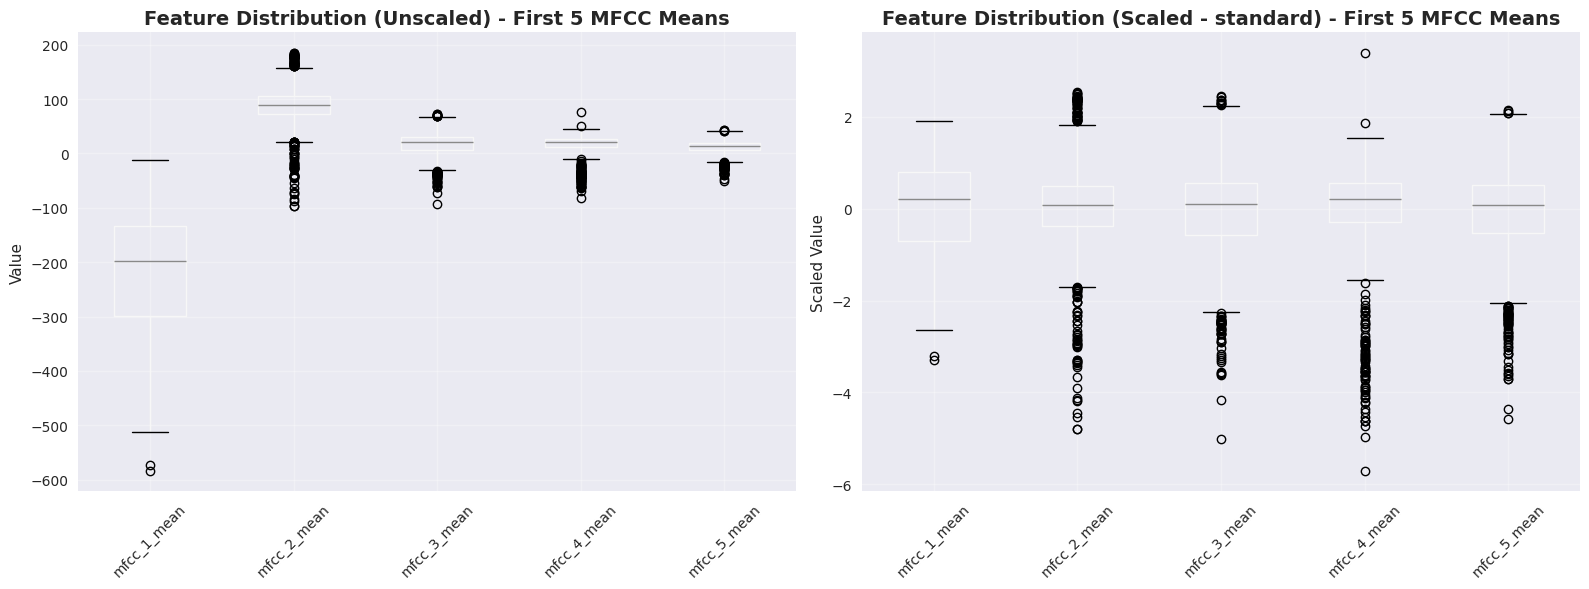

✓ Feature scaling comparison plot saved


In [7]:
# Feature distribution before and after scaling
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Plot unscaled features (first 5 MFCCs as example)
sample_features = [col for col in feature_columns if 'mfcc' in col and 'mean' in col][:5]
features_df[sample_features].boxplot(ax=axes[0])
axes[0].set_title('Feature Distribution (Unscaled) - First 5 MFCC Means', 
                   fontsize=14, fontweight='bold')
axes[0].set_ylabel('Value')
axes[0].tick_params(axis='x', rotation=45)
axes[0].grid(True, alpha=0.3)

# Plot scaled features
scaled_features_df[sample_features].boxplot(ax=axes[1])
axes[1].set_title(f'Feature Distribution (Scaled - {CONFIG["SCALING_METHOD"]}) - First 5 MFCC Means', 
                   fontsize=14, fontweight='bold')
axes[1].set_ylabel('Scaled Value')
axes[1].tick_params(axis='x', rotation=45)
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig(FEATURES_DIR / 'feature_scaling_comparison.png', dpi=300, bbox_inches='tight')
plt.show()

print("✓ Feature scaling comparison plot saved")

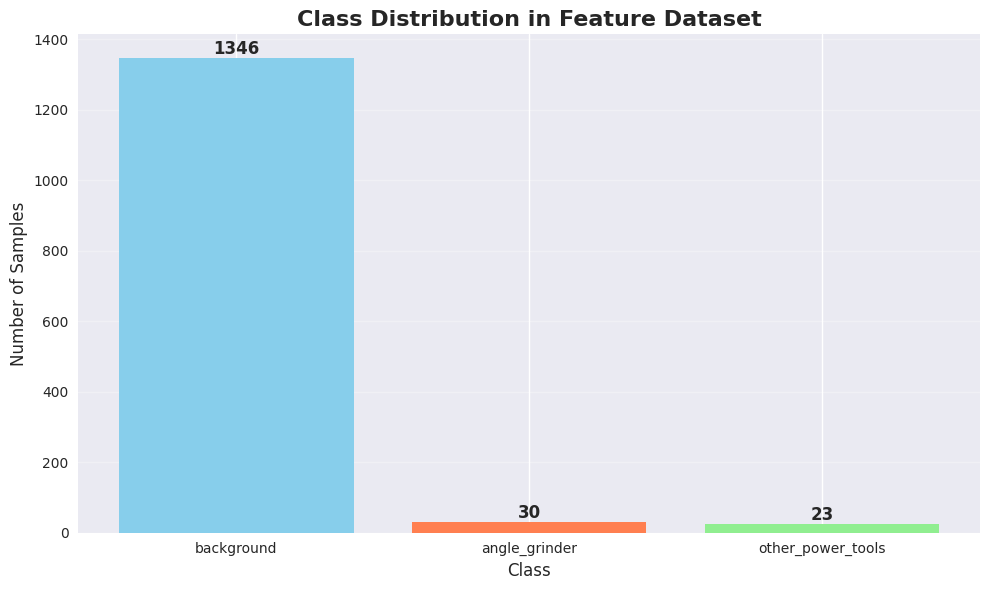

✓ Class distribution plot saved


In [8]:
# Class balance visualization
fig, ax = plt.subplots(figsize=(10, 6))
class_counts = features_df['class'].value_counts()
colors = ['skyblue', 'coral', 'lightgreen']
bars = ax.bar(class_counts.index, class_counts.values, color=colors[:len(class_counts)])

ax.set_title('Class Distribution in Feature Dataset', fontsize=16, fontweight='bold')
ax.set_xlabel('Class', fontsize=12)
ax.set_ylabel('Number of Samples', fontsize=12)
ax.grid(True, alpha=0.3, axis='y')

# Add value labels on bars
for bar in bars:
    height = bar.get_height()
    ax.text(bar.get_x() + bar.get_width()/2., height,
            f'{int(height)}',
            ha='center', va='bottom', fontsize=12, fontweight='bold')

plt.tight_layout()
plt.savefig(FEATURES_DIR / 'class_distribution.png', dpi=300, bbox_inches='tight')
plt.show()

print("✓ Class distribution plot saved")

Generating correlation heatmap for subset of features...


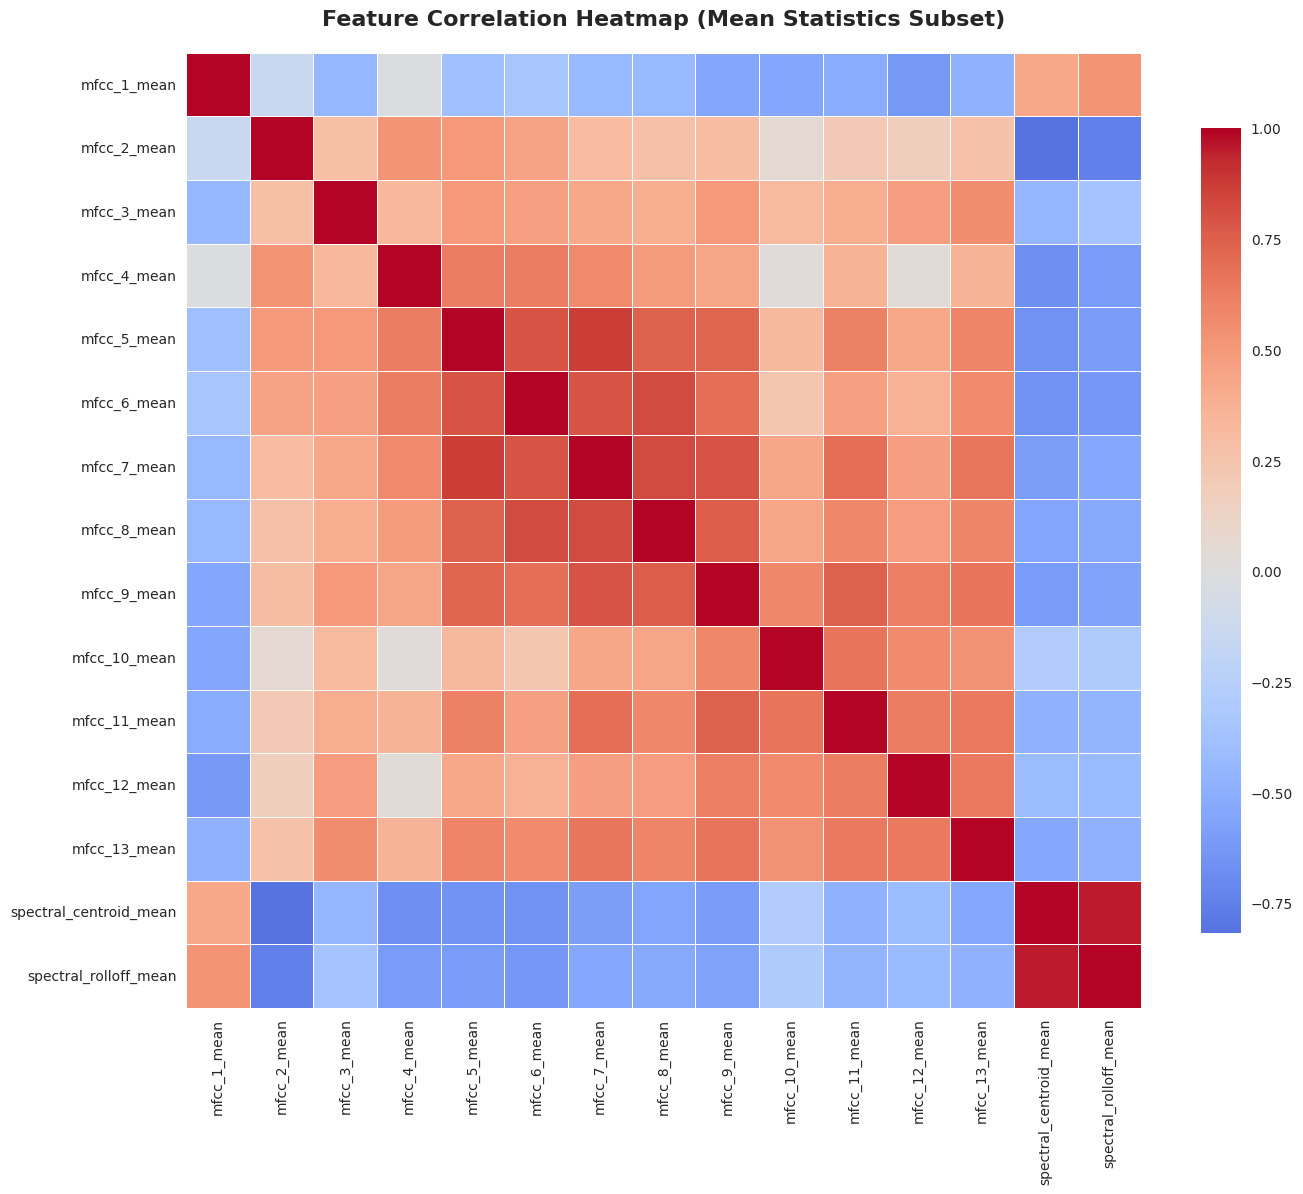

✓ Correlation heatmap saved


In [9]:
# Feature correlation heatmap (subset of features)
print("Generating correlation heatmap for subset of features...")
subset_features = [col for col in feature_columns if 'mean' in col][:15]  # First 15 mean features

correlation_matrix = scaled_features_df[subset_features].corr()

plt.figure(figsize=(14, 12))
sns.heatmap(correlation_matrix, annot=False, cmap='coolwarm', center=0, 
            square=True, linewidths=0.5, cbar_kws={"shrink": 0.8})
plt.title('Feature Correlation Heatmap (Mean Statistics Subset)', 
          fontsize=16, fontweight='bold', pad=20)
plt.tight_layout()
plt.savefig(FEATURES_DIR / 'feature_correlation_heatmap.png', dpi=300, bbox_inches='tight')
plt.show()

print("✓ Correlation heatmap saved")

## Summary Statistics

In [10]:
# Calculate feature breakdown
n_mfcc_features = CONFIG['N_MFCC_START'] * 3  # mean, std, median
n_spectral_features = 5 * 3  # centroid, rolloff, zcr, rms, bandwidth × 3 stats
n_contrast_features = 7 * 3  # 7 bands × 3 stats

print(f"\n{'='*60}")
print("FEATURE EXTRACTION COMPLETE")
print(f"{'='*60}")
print(f"\nDataset Summary:")
print(f"  Total samples: {len(features_df)}")
print(f"  Total features per sample: {len(feature_columns)}")
print(f"  Feature breakdown:")
print(f"    - MFCC features: {CONFIG['N_MFCC_START']} coefficients × 3 statistics = {n_mfcc_features}")
print(f"    - Spectral features: 5 features × 3 statistics = {n_spectral_features}")
print(f"    - Spectral contrast: 7 bands × 3 statistics = {n_contrast_features}")
print(f"    - Total: {n_mfcc_features + n_spectral_features + n_contrast_features}")

print(f"\nClass distribution:")
for cls in CLASSES:
    count = len(features_df[features_df['class'] == cls])
    if count > 0:
        percentage = (count / len(features_df)) * 100
        print(f"  {cls}: {count} samples ({percentage:.1f}%)")

print(f"\nFiles saved to: {FEATURES_DIR}")
print(f"  - classical_features_unscaled.csv")
print(f"  - classical_features_scaled.csv")
print(f"  - feature_scaler_{CONFIG['SCALING_METHOD']}.pkl")
print(f"  - feature_names.txt")
print(f"  - extraction_config.json")
print(f"  - Visualization plots (PNG files)")
print(f"\n✓ Ready for classical ML model training (notebook 04)!")


FEATURE EXTRACTION COMPLETE

Dataset Summary:
  Total samples: 1399
  Total features per sample: 75
  Feature breakdown:
    - MFCC features: 13 coefficients × 3 statistics = 39
    - Spectral features: 5 features × 3 statistics = 15
    - Spectral contrast: 7 bands × 3 statistics = 21
    - Total: 75

Class distribution:
  background: 1346 samples (96.2%)
  angle_grinder: 30 samples (2.1%)
  other_power_tools: 23 samples (1.6%)

Files saved to: /workspaces/BikeAIv2/data/features
  - classical_features_unscaled.csv
  - classical_features_scaled.csv
  - feature_scaler_standard.pkl
  - feature_names.txt
  - extraction_config.json
  - Visualization plots (PNG files)

✓ Ready for classical ML model training (notebook 04)!
